In [1]:
import pandas as pd
import geopandas as gpd
import re
from shapely.geometry import Point

pedestrian_df = pd.read_csv("Bi-Annual_Pedestrian_Counts.csv")
print(pedestrian_df.head())
print(pedestrian_df.info())

                                        the_geom  OBJECTID  Loc Borough  \
0   POINT (-73.90459140730678 40.87919896648574)         1    1   Bronx   
1   POINT (-73.92188432870218 40.82662794123292)         2    2   Bronx   
2   POINT (-73.89535781584335 40.86215460031517)         3    3   Bronx   
3    POINT (-73.87892467324478 40.8812869959873)         4    4   Bronx   
4  POINT (-73.88956389732787 40.844636776717664)         5    5   Bronx   

            Street_Nam         From_Stree          To_Street Iex May07_AM  \
0             Broadway  West 231st Street     Naples Terrace   N    1,189   
1    East 161st Street      Gra Concourse    Sheridan Avenue   Y    1,511   
2    East Fordham Road   Valentine Avenue     Tiebout Avenue   Y    1,832   
3   East Gun Hill Road  Bainbridge Avenue  Rochambeau Avenue   N      764   
4  East Tremont Avenue    Prospect Avenue     Clinton Avenue   N      650   

  May07_PM  ... Oct23_MD June24_AM June24_PM June24_MD Oct24_AM Oct24_PM  \
0    4,094

In [2]:
# Identify and clean time series columns
time_cols = [c for c in pedestrian_df.columns if re.search(r'(May|Sept|Oct|June)\d{2}_(AM|PM|MD)', c, re.IGNORECASE)]
print(time_cols)

['May07_AM', 'May07_PM', 'May07_MD', 'Sept07_AM', 'Sept07_PM', 'Sept07_MD', 'May08_AM', 'May08_PM', 'May08_MD', 'Sept08_AM', 'Sept08_PM', 'Sept08_MD', 'May09_AM', 'May09_PM', 'May09_MD', 'Sept09_AM', 'Sept09_PM', 'Sept09_MD', 'May10_AM', 'May10_PM', 'May10_MD', 'Sept10_AM', 'Sept10_PM', 'Sept10_MD', 'May11_AM', 'May11_PM', 'May11_MD', 'Sept11_AM', 'Sept11_PM', 'Sept11_MD', 'May12_AM', 'May12_PM', 'May12_MD', 'Sept12_AM', 'Sept12_PM', 'Sept12_MD', 'May13_AM', 'May13_PM', 'May13_MD', 'Sept13_AM', 'Sept13_PM', 'Sept13_MD', 'May14_AM', 'May14_PM', 'May14_MD', 'Sept14_AM', 'Sept14_PM', 'Sept14_MD', 'May15_AM', 'May15_PM', 'May15_MD', 'Sept15_AM', 'Sept15_PM', 'Sept15_MD', 'May16_AM', 'May16_PM', 'May16_MD', 'Sept16_AM', 'Sept16_PM', 'Sept16_MD', 'May17_AM', 'May17_PM', 'May17_MD', 'Sept17_AM', 'Sept17_PM', 'Sept17_MD', 'May18_AM', 'May18_PM', 'May18_MD', 'Sept18_AM', 'Sept18_PM', 'Sept18_MD', 'May19_AM', 'May19_PM', 'May19_MD', 'Oct20_AM', 'Oct20_PM', 'Oct20_MD', 'May21_AM', 'May21_PM', 'Ma

In [3]:
def clean_currency(x):
    if isinstance(x, str):
        return pd.to_numeric(x.replace(",", ""), errors='coerce')
    return x

for col in time_cols:
    pedestrian_df[col] = pedestrian_df[col].apply(clean_currency)

print(pedestrian_df.head())

                                        the_geom  OBJECTID  Loc Borough  \
0   POINT (-73.90459140730678 40.87919896648574)         1    1   Bronx   
1   POINT (-73.92188432870218 40.82662794123292)         2    2   Bronx   
2   POINT (-73.89535781584335 40.86215460031517)         3    3   Bronx   
3    POINT (-73.87892467324478 40.8812869959873)         4    4   Bronx   
4  POINT (-73.88956389732787 40.844636776717664)         5    5   Bronx   

            Street_Nam         From_Stree          To_Street Iex  May07_AM  \
0             Broadway  West 231st Street     Naples Terrace   N      1189   
1    East 161st Street      Gra Concourse    Sheridan Avenue   Y      1511   
2    East Fordham Road   Valentine Avenue     Tiebout Avenue   Y      1832   
3   East Gun Hill Road  Bainbridge Avenue  Rochambeau Avenue   N       764   
4  East Tremont Avenue    Prospect Avenue     Clinton Avenue   N       650   

   May07_PM  ...  Oct23_MD  June24_AM  June24_PM  June24_MD  Oct24_AM  \
0      

In [4]:
#Calculate monthly totals(AM + PM + MD)

prefixes = set()
for col in time_cols:
    match = re.match(r"((?:May|Sept|Oct|June)\d{2})_(?:AM|PM|MD)", col, re.IGNORECASE)
    if match:
        prefixes.add(match.group(1))

print(prefixes)

{'Sept18', 'May11', 'May18', 'May09', 'May07', 'May10', 'May21', 'May16', 'May14', 'Sept17', 'Sept16', 'Sept12', 'Sept15', 'Oct22', 'Oct23', 'May25', 'Oct21', 'May17', 'May12', 'June24', 'Oct20', 'Sept14', 'Sept10', 'Sept08', 'May08', 'Sept11', 'Sept13', 'Sept07', 'May19', 'May15', 'May23', 'May22', 'May13', 'Oct24', 'Sept09'}


In [5]:
month_year_totals = pd.DataFrame()
for prefix in prefixes:
    relevant_cols = [c for c in time_cols if c.upper().startswith(prefix.upper() + '_')]
    if relevant_cols:
        month_year_totals[prefix] = pedestrian_df[relevant_cols].sum(axis = 1, min_count=1)

print(month_year_totals.head())

   Sept18  May11  May18  May09  May07  May10  May21  May16  May14  Sept17  \
0    9139   8124   8672   7308   7791   7747   5602   8463   8245    7886   
1    8333   6839   9053   5766   6666   6769   4912   9085   8884   11173   
2   17389  27346  18909  17535  28534  23652  10920  22234  21528   22247   
3    6319   6015   5863   6205   5235   8633   3318   6762   6807    7433   
4    7197  11486   7362   5948   5522  10983   4210   7110   7017    6891   

   ...  Sept11  Sept13  Sept07  May19  May15  May23  May22  May13  Oct24  \
0  ...    7576    8804    6319      0   9801   9411   4963   9745   7357   
1  ...    7328    7793    6792   7625   9390   9048   8637   8781   9356   
2  ...   24367   21505   26109  20832  21172  13268  12438  24305  12511   
3  ...    6419    7947    4207      0   7032   4981   4495   8012   5042   
4  ...   10842    7053    6160      0   7319   4385   3783   8036   4942   

   Sept09  
0    7722  
1    7126  
2   19656  
3    6823  
4    6888  

[5 rows

In [6]:
years = set()
for p in prefixes:
    match = re.search(r'\d{2}$', p)
    if match:
        years.add(match.group(0))

sorted_years = sorted(list(years))
print(sorted_years)

['07', '08', '09', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25']


In [7]:
year_counts = pd.DataFrame()

for yr in sorted_years:
    cols_for_year = [c for c in month_year_totals.columns if c.endswith(yr)]
    if cols_for_year:
        full_year = f'20{yr}'
        year_counts[full_year] = month_year_totals[cols_for_year].mean(axis=1)

print(year_counts.head())

      2007     2008     2009     2010     2011     2012     2013     2014  \
0   7055.0   8151.5   7515.0   7473.0   7850.0   7920.0   9274.5   8668.5   
1   6729.0   5950.5   6446.0   6161.0   7083.5   6601.0   8287.0   8828.0   
2  27321.5  18760.5  18595.5  23415.5  25856.5  18696.5  22905.0  21477.0   
3   4721.0   7947.0   6514.0   7302.5   6217.0   6362.0   7979.5   6976.5   
4   5841.0   4934.0   6418.0  10769.0  11164.0   5436.5   7544.5   6793.0   

      2015     2016     2017     2018     2019     2020     2021     2022  \
0   9262.0   8122.0   9235.5   8905.5      0.0   5083.0   5723.5   5293.0   
1   9348.5   9613.5  10042.0   8693.0   7625.0   3959.0   6329.5   8694.5   
2  21781.5  22788.0  21714.0  18149.0  20832.0  13006.0  12439.0  12718.5   
3   6892.5   6504.5   6905.5   6091.0      0.0   4201.0   3744.0   4547.5   
4   7072.0   7024.0   7048.5   7279.5      0.0   4073.0   4391.0   4126.0   

      2023     2024     2025  
0   7925.0   6896.0   5455.0  
1   9103.5  

In [8]:
metadata_cols = [c for c in pedestrian_df.columns if c not in time_cols]
processed_df = pd.concat([pedestrian_df[metadata_cols], year_counts],axis=1)

print(processed_df.head())

                                        the_geom  OBJECTID  Loc Borough  \
0   POINT (-73.90459140730678 40.87919896648574)         1    1   Bronx   
1   POINT (-73.92188432870218 40.82662794123292)         2    2   Bronx   
2   POINT (-73.89535781584335 40.86215460031517)         3    3   Bronx   
3    POINT (-73.87892467324478 40.8812869959873)         4    4   Bronx   
4  POINT (-73.88956389732787 40.844636776717664)         5    5   Bronx   

            Street_Nam         From_Stree          To_Street Iex     2007  \
0             Broadway  West 231st Street     Naples Terrace   N   7055.0   
1    East 161st Street      Gra Concourse    Sheridan Avenue   Y   6729.0   
2    East Fordham Road   Valentine Avenue     Tiebout Avenue   Y  27321.5   
3   East Gun Hill Road  Bainbridge Avenue  Rochambeau Avenue   N   4721.0   
4  East Tremont Avenue    Prospect Avenue     Clinton Avenue   N   5841.0   

      2008  ...     2016     2017     2018     2019     2020     2021  \
0   8151.5  .

In [9]:
# Match community districts
nta_map = gpd.read_file("../nyc311/nta_boundaries.geojson")
print(nta_map.shape)

(262, 12)


In [10]:
def parse_point(geom_str):
    if pd.isna(geom_str):
        return None
    clean = geom_str.replace("POINT (", "").replace(")", "")
    parts = clean.split()
    return Point(float(parts[0]), float(parts[1]))

processed_df['geometry'] = processed_df['the_geom'].apply(parse_point)

print(processed_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   the_geom    114 non-null    object 
 1   OBJECTID    114 non-null    int64  
 2   Loc         114 non-null    int64  
 3   Borough     114 non-null    object 
 4   Street_Nam  114 non-null    object 
 5   From_Stree  114 non-null    object 
 6   To_Street   96 non-null     object 
 7   Iex         114 non-null    object 
 8   2007        114 non-null    float64
 9   2008        114 non-null    float64
 10  2009        114 non-null    float64
 11  2010        114 non-null    float64
 12  2011        114 non-null    float64
 13  2012        114 non-null    float64
 14  2013        114 non-null    float64
 15  2014        114 non-null    float64
 16  2015        114 non-null    float64
 17  2016        114 non-null    float64
 18  2017        114 non-null    float64
 19  2018        114 non-null    f

In [11]:
ped_gdf = gpd.GeoDataFrame(processed_df, geometry='geometry', crs="EPSG:4326")

if nta_map.crs != ped_gdf.crs:
    cd_map = nta_map.to_crs[ped_gdf.crs]

joined_gdf = gpd.sjoin(ped_gdf, nta_map, how='left', predicate='within')


final_columns = [col for col in joined_gdf.columns if col != 'index_right']
final_df = joined_gdf[final_columns].copy()

nta_columns = [col for col in final_df.columns if 'nta' in col.lower() or 'nta2020' in col.lower()]
display_cols = nta_columns + list(year_counts.columns) + ['geometry', 'Location', 'Address']
available_cols = [col for col in display_cols if col in final_df.columns]
final_df = final_df[available_cols]
final_df.dropna(inplace=True)
print(final_df.info())
print(final_df)


output_file = 'Pedestrian_Counts_Annual_With_Community_Districts.csv'
final_df.to_csv(output_file, index=False)
print(f"\nResults saved to: {output_file}")



<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 101 entries, 0 to 104
Data columns (total 24 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   NTA2020    101 non-null    object  
 1   NTAName    101 non-null    object  
 2   NTAAbbrev  101 non-null    object  
 3   NTAType    101 non-null    object  
 4   2007       101 non-null    float64 
 5   2008       101 non-null    float64 
 6   2009       101 non-null    float64 
 7   2010       101 non-null    float64 
 8   2011       101 non-null    float64 
 9   2012       101 non-null    float64 
 10  2013       101 non-null    float64 
 11  2014       101 non-null    float64 
 12  2015       101 non-null    float64 
 13  2016       101 non-null    float64 
 14  2017       101 non-null    float64 
 15  2018       101 non-null    float64 
 16  2019       101 non-null    float64 
 17  2020       101 non-null    float64 
 18  2021       101 non-null    float64 
 19  2022       101 non-null   

Shapefile loaded successfully.


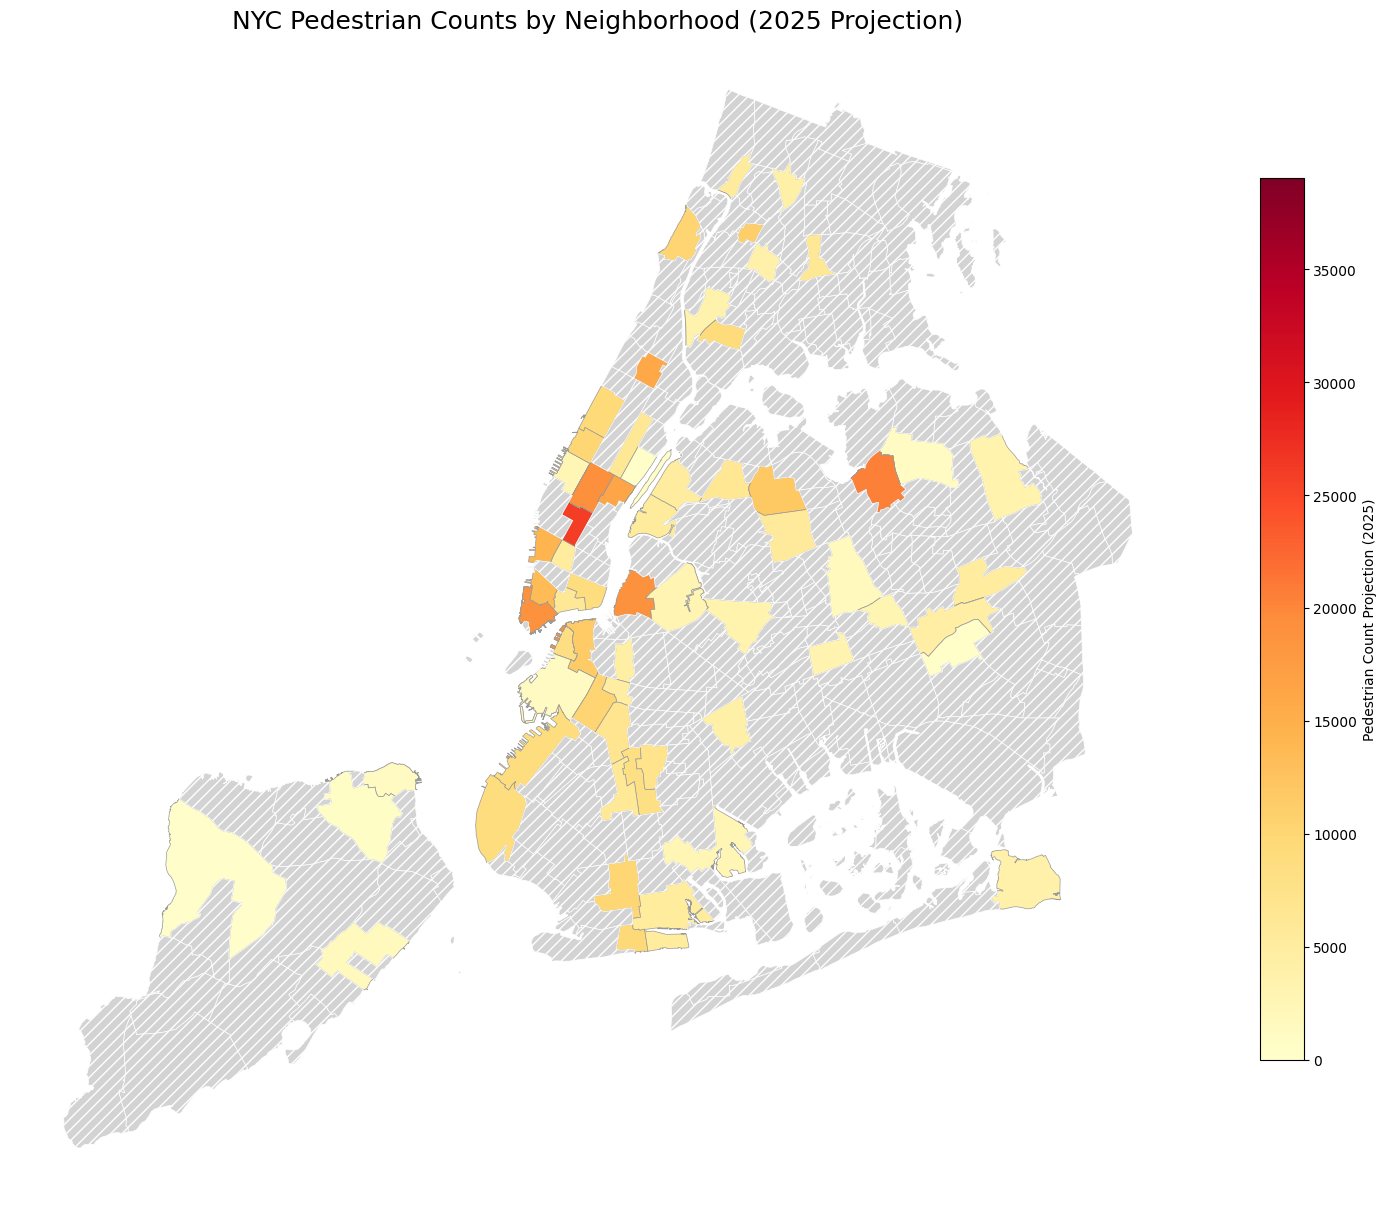

In [12]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import zipfile
import os

zip_file_path = '../nyc311/nynta2020_25d.zip'
extract_dir = 'nynta2020_25d'

if not os.path.exists(extract_dir):
    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)
        print("Extraction complete.")
    except FileNotFoundError:
        print(f"Error: The file '{zip_file_path}' was not found.")
        exit()

shp_file_path = os.path.join(extract_dir, 'nynta2020_25d', 'nynta2020.shp')

csv_path = 'Pedestrian_Counts_Annual_With_Community_Districts.csv'
df_counts = pd.read_csv(csv_path)
df_subset = df_counts[['NTA2020', '2025']].copy()
df_subset['NTA2020'] = df_subset['NTA2020'].astype(str)

nyc_nta_geo = gpd.read_file(shp_file_path)
nyc_nta_geo['NTA2020'] = nyc_nta_geo['NTA2020'].astype(str)
print("Shapefile loaded successfully.")

# Merge the map data with the pedestrian count data on 'NTA2020'
nta_merged = nyc_nta_geo.merge(df_subset, on='NTA2020', how='left')

fig, ax = plt.subplots(1, 1, figsize=(15, 15))

nta_merged.plot(
    column='2025',          
    cmap='YlOrRd',         
    linewidth=0.5,
    ax=ax,
    edgecolor='0.6',        
    legend=True,
    legend_kwds={
        'label': "Pedestrian Count Projection (2025)", 
        'shrink': 0.6
    },
    missing_kwds={         
        "color": "lightgrey",
        "edgecolor": "white",
        "hatch": "///",
        "label": "No Data"
    }
)

ax.set_title('NYC Pedestrian Counts by Neighborhood (2025 Projection)', fontsize=18)
ax.set_axis_off() 

plt.tight_layout()
plt.show()